In [ ]:
!pip install ultralytics datasets opencv-python numpy pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 62.4 MB/s eta 0:00:00


In [ ]:
from datasets import load_dataset

print('Loading dataset...')
ds = load_dataset('justjuu/license-plate-detection')

df_train = ds['train'].to_pandas()
df_val   = ds['validation'].to_pandas()
df_test  = ds['test'].to_pandas()

print(f'✅ Dataset loaded!')
print(f'   Train      : {len(df_train)} images')
print(f'   Validation : {len(df_val)} images')
print(f'   Test       : {len(df_test)} images')

Loading dataset...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/168M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/46.2M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/22.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6176 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1765 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/882 [00:00<?, ? examples/s]

✅ Dataset loaded!
   Train      : 6176 images
   Validation : 1765 images
   Test       : 882 images


Sample keys  : ['image', 'objects']
Objects      : {'bbox': array([array([185., 231., 107.,  37.], dtype=float32)], dtype=object), 'category': array([0])}
BBox format  : [x_min, y_min, width, height] (COCO format)


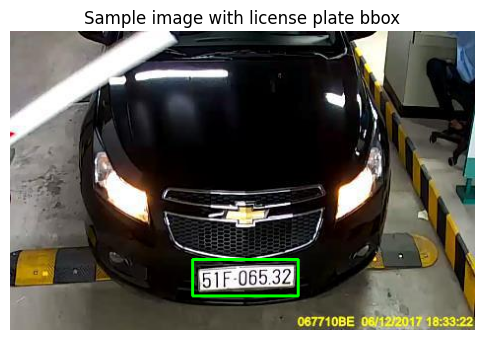

In [ ]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

# Look at first sample
sample = df_train.iloc[0]
print('Sample keys  :', sample.index.tolist())
print('Objects      :', sample['objects'])
print('BBox format  : [x_min, y_min, width, height] (COCO format)')

# Display sample image with bbox
image = np.frombuffer(sample['image'].get('bytes'), dtype=np.uint8)
image = cv2.imdecode(image, cv2.IMREAD_COLOR)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

bbox = sample['objects']['bbox'][0]  # [x_min, y_min, w, h]
x, y, w, h = map(int, bbox)
cv2.rectangle(image_rgb, (x, y), (x+w, y+h), (0, 255, 0), 2)

plt.figure(figsize=(6, 4))
plt.imshow(image_rgb)
plt.title('Sample image with license plate bbox')
plt.axis('off')
plt.show()

In [ ]:
import os

def save_split(df, split_name):
    """
    Convert HuggingFace dataset split to YOLO format.
    Saves images as .jpg and labels as .txt
    BBox: COCO format [x_min, y_min, width, height] → YOLO [x_center, y_center, w, h] normalized
    """
    image_dir = f'dataset/images/{split_name}'
    label_dir = f'dataset/labels/{split_name}'
    os.makedirs(image_dir, exist_ok=True)
    os.makedirs(label_dir, exist_ok=True)

    skipped = 0
    saved   = 0

    for idx, row in df.iterrows():
        # --- Load image from bytes ---
        img_bytes = row['image'].get('bytes')
        if img_bytes is None:
            skipped += 1
            continue

        image = np.frombuffer(img_bytes, dtype=np.uint8)
        image = cv2.imdecode(image, cv2.IMREAD_COLOR)

        if image is None:
            skipped += 1
            continue

        img_h, img_w = image.shape[:2]

        # --- Save image ---
        img_path = os.path.join(image_dir, f'image_{idx}.jpg')
        cv2.imwrite(img_path, image)

        # --- Convert bbox to YOLO format ---
        bboxes     = row['objects'].get('bbox', [])    # list of [x_min, y_min, w, h]
        categories = row['objects'].get('category', [])

        label_path = os.path.join(label_dir, f'image_{idx}.txt')
        with open(label_path, 'w') as f:
            for bbox, cat in zip(bboxes, categories):
                x_min, y_min, bw, bh = bbox

                # Normalize to 0-1 range (YOLO format)
                x_center = (x_min + bw / 2) / img_w
                y_center = (y_min + bh / 2) / img_h
                bw_norm  = bw / img_w
                bh_norm  = bh / img_h

                # Clamp to [0, 1] just in case
                x_center = max(0, min(1, x_center))
                y_center = max(0, min(1, y_center))
                bw_norm  = max(0, min(1, bw_norm))
                bh_norm  = max(0, min(1, bh_norm))

                f.write(f'{int(cat)} {x_center:.6f} {y_center:.6f} {bw_norm:.6f} {bh_norm:.6f}\n')

        saved += 1

    print(f'✅ {split_name:10s} → {saved} saved, {skipped} skipped')


print('Preprocessing dataset...')
save_split(df_train, 'train')
save_split(df_val,   'val')
save_split(df_test,  'test')
print('\n✅ All splits saved to dataset/')

Preprocessing dataset...
✅ train      → 6176 saved, 0 skipped
✅ val        → 1765 saved, 0 skipped
✅ test       → 882 saved, 0 skipped

✅ All splits saved to dataset/


In [ ]:
import yaml

dataset_yaml = {
    'path'  : 'dataset',
    'train' : 'images/train',
    'val'   : 'images/val',
    'test'  : 'images/test',
    'nc'    : 1,
    'names' : ['license_plate']
}

with open('dataset.yaml', 'w') as f:
    yaml.dump(dataset_yaml, f, default_flow_style=False)

print('✅ dataset.yaml created!')
print(open('dataset.yaml').read())

✅ dataset.yaml created!
names:
- license_plate
nc: 1
path: dataset
test: images/test
train: images/train
val: images/val



In [ ]:
from ultralytics import YOLO

# Load base yolov8n model (downloads automatically)
model = YOLO('yolov8n.pt')

# Fine-tune
results = model.train(
    data    = 'dataset.yaml',
    epochs  = 50,           # 50 is enough for fine-tuning
    imgsz   = 640,
    batch   = 16,
    device  = 0,            # GPU
    lr0     = 0.001,        # low learning rate for fine-tuning
    patience = 10,          # stop early if no improvement for 10 epochs
    project = 'runs',
    name    = 'license_plate_v1',
    exist_ok = True
)

print('\n✅ Training complete!')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.18 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False

In [ ]:
from ultralytics import YOLO

# Evaluate fine-tuned
print('Evaluating fine-tuned model...')
finetuned = YOLO('runs/detect/runs/license_plate_v1/weights/best.pt')
metrics = finetuned.val(data='dataset.yaml', split='test')

print('\n📊 Evaluation Results:')
print(f'   mAP50     : {metrics.box.map50:.3f}')   # main metric
print(f'   mAP50-95  : {metrics.box.map:.3f}')
print(f'   Precision : {metrics.box.mp:.3f}')
print(f'   Recall    : {metrics.box.mr:.3f}')

Evaluating fine-tuned model...
Ultralytics 8.4.18 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1477.0±458.8 MB/s, size: 36.3 KB)
val: Scanning /content/dataset/labels/test.cache... 882 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 882/882 246.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 56/56 13.3it/s 4.2s
                   all        882        902      0.994      0.972       0.99      0.734
Speed: 0.5ms preprocess, 0.7ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /content/runs/detect/val5

📊 Evaluation Results:
   mAP50     : 0.990
   mAP50-95  : 0.734
   Precision : 0.994
   Recall    : 0.972


In [ ]:
from google.colab import files

# Download best.pt to your local machine
files.download('runs/detect/runs/license_plate_v1/weights/best.pt')
print('✅ best.pt downloaded!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ best.pt downloaded!
